# SRCNN Training

## Objective

The goal of this notebook is to verify that the complete training pipeline works correctly.

The notebook performs:

- model initialization;
- DataLoader creation;
- loss definition;
- optimizer definition;
- execution of one training epoch.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn

from src.models.srcnn import SRCNN
from src.dataloader import get_train_loader
from src.train import train_one_epoch
from src.config import LEARNING_RATE, NUM_EPOCHS
from src.evaluate import evaluate
from src.dataloader import get_valid_loader

## Device

Select the device used for training.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## DataLoader

In [4]:
train_loader = get_train_loader()
valid_loader = get_valid_loader()

## Model

In [5]:
model = SRCNN().to(device)

print(model)

SRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): ReLU(inplace=True)
  )
  (mapping): Sequential(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (reconstruction): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


## Loss Function

In [6]:
criterion = nn.MSELoss()

## Optimizer

In [7]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [8]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

## One Training Epoch

In [9]:
from src.checkpoint import save_model
TRAIN_EPOCHS = 200

loss_history = []
best_psnr = 0.0

patience = 20
epochs_without_improvement = 0

train_loss_history = []
valid_loss_history = []
valid_psnr_history = []

for epoch in range(TRAIN_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_psnr = evaluate(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=device
    )

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_psnr_history.append(valid_psnr)

    print(
        f"Epoch {epoch+1}/{TRAIN_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Valid Loss: {valid_loss:.6f} | "
        f"PSNR: {valid_psnr:.2f} dB | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if valid_psnr > best_psnr:

        best_psnr = valid_psnr

        epochs_without_improvement = 0

        save_model(
            model,
            "../results/checkpoints/srcnn_best.pth"
        )

        print("Best model saved!")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print("\nEarly stopping activated!")

        break
    scheduler.step()
    

Epoch 1/200 | Train Loss: 0.110025 | Valid Loss: 0.024064 | PSNR: 16.23 dB | LR: 0.000100
Best model saved!
Epoch 2/200 | Train Loss: 0.019670 | Valid Loss: 0.016565 | PSNR: 17.84 dB | LR: 0.000100
Best model saved!
Epoch 3/200 | Train Loss: 0.013165 | Valid Loss: 0.010000 | PSNR: 20.01 dB | LR: 0.000100
Best model saved!
Epoch 4/200 | Train Loss: 0.009547 | Valid Loss: 0.007050 | PSNR: 21.59 dB | LR: 0.000100
Best model saved!
Epoch 5/200 | Train Loss: 0.006567 | Valid Loss: 0.005846 | PSNR: 22.43 dB | LR: 0.000100
Best model saved!
Epoch 6/200 | Train Loss: 0.005199 | Valid Loss: 0.005050 | PSNR: 23.01 dB | LR: 0.000100
Best model saved!
Epoch 7/200 | Train Loss: 0.004674 | Valid Loss: 0.004072 | PSNR: 23.97 dB | LR: 0.000100
Best model saved!
Epoch 8/200 | Train Loss: 0.003984 | Valid Loss: 0.004038 | PSNR: 23.99 dB | LR: 0.000100
Best model saved!
Epoch 9/200 | Train Loss: 0.003954 | Valid Loss: 0.003272 | PSNR: 24.97 dB | LR: 0.000100
Best model saved!
Epoch 10/200 | Train Loss: 0

In [10]:
from src.checkpoint import save_checkpoint

save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=10,
    best_psnr=36.33,
    filepath="../results/checkpoints/srcnn_training_checkpoint.pth"
)

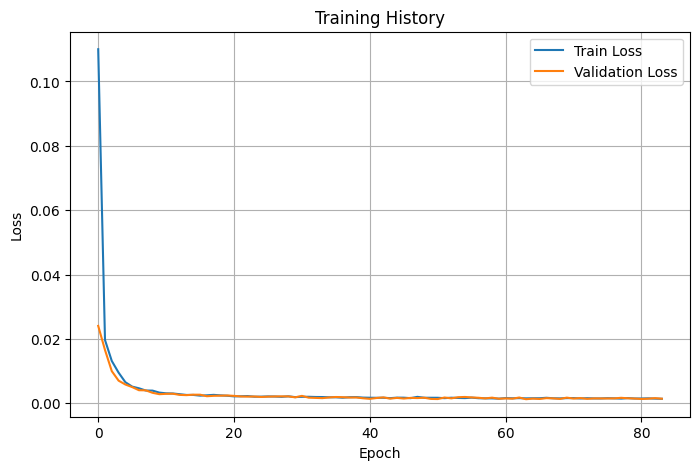

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")

plt.legend()
plt.grid(True)

plt.show()

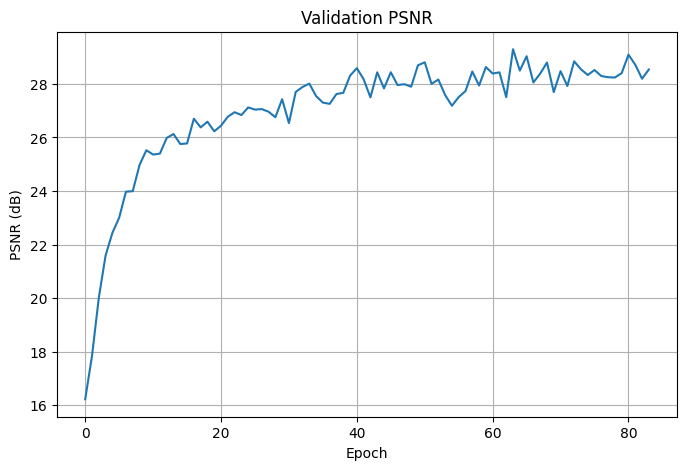

In [12]:
plt.figure(figsize=(8,5))

plt.plot(valid_psnr_history)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Validation PSNR")

plt.grid(True)

plt.show()

In [13]:
import json

history = {
    "train_loss": train_loss_history,
    "valid_loss": valid_loss_history,
    "valid_psnr": valid_psnr_history
}

with open("../results/metrics/srcnn_training_history.json", "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved.")

Training history saved.


In [14]:
from src.checkpoint import save_model
save_model(
    model,
    "../results/checkpoints/srcnn_x2_200epochs.pth"
)

In [15]:
from src.checkpoint import load_model
model = load_model(
    model,
    "../results/checkpoints/srcnn_x2_200epochs.pth",
    device
)

c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)
